# Customer Behavior Analytics

# Data Cleaning

1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

2. Load the dataset

In [2]:
df = pd.read_csv("customer_shopping_trend.csv")

3. Initial Inspection

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [ ]:
df.shape

(3900, 18)

In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


4. Check Missing Values

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


5. Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

6. Check Unique Values:
This helps in understanding the Categories, Payment methods, Seasons, Sizes, Shipping types, etc smoothly.

In [ ]:
for col in df.select_dtypes(include='object'):
  print(col)
  print(df[col].unique())
  print("-"*40)

Gender
['Male' 'Female']
----------------------------------------
Item Purchased
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']
----------------------------------------
Category
['Clothing' 'Footwear' 'Outerwear' 'Accessories']
----------------------------------------
Location
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota

7. Create New Features

In [3]:
# Age Group

bins = [18, 25, 35, 45, 55, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True)

In [ ]:
# Spending Level

df["Spending Level"] = pd.qcut(
    df["Purchase Amount (USD)"],
    q=3,
    labels = ["Low", "Medium", "High"]
)

In [ ]:
# Loyalty Level

df["Loyalty Level"] = pd.cut(
    df["Previous Purchases"],
    bins=[0, 15, 30, 45, 60],
    labels=[
        "New",
        "Regular",
        "Loyal",
        "VIP"
    ]
)

8. Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_customer_data.csv", index=False)

9. Dataset Summary:

The dataset contains 3,900 customer purchase records with 18 original features representing customer demographics, purchasing behavior, product information, and transaction details. The dataset contains no missing values and is well structured for exploratory data analysis, customer segmentation, and dashboard development. To support deeper analysis, additional features such as Age Group, Spending Level, and Loyalty Level were derived from the existing variables.

# EDA

In [4]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# 1. Load the cleaned dataset

In [5]:
df = pd.read_csv("cleaned_customer_data.csv")

# 2. Overall dataset summary

In [6]:
print(df.shape)
print(df.describe())
print(df.describe(include='object'))

(3900, 21)
       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  
       Gender Item Purchased  Category Location  Size  Color  Season  \
count  

# 3. Customer Demographics

# Chart 1: Gender Distribution

Helps in identifying Which gender has more customers and whether the distribution is balanced or not.

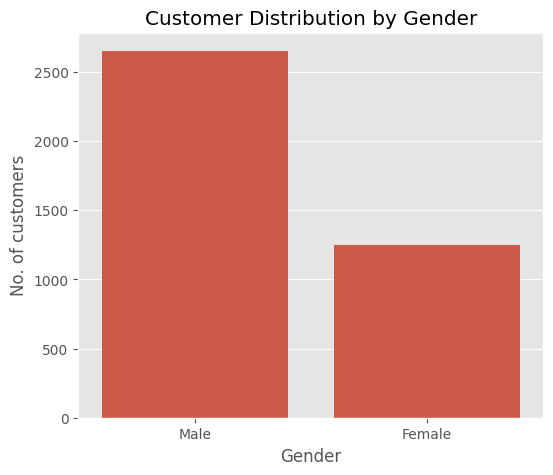

In [7]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x = 'Gender')

plt.title('Customer Distribution by Gender')
plt.xlabel("Gender")
plt.ylabel("No. of customers")
plt.show()

# Chart 2: Age Distribution

This will give which age range dominates &
tell us that the customer base young or middle-aged.

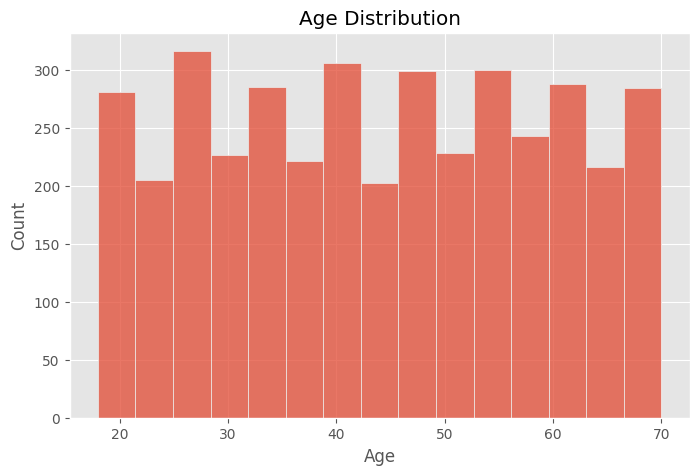

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# Chart 3: Age Group Analysis

Answers which age group shops the most

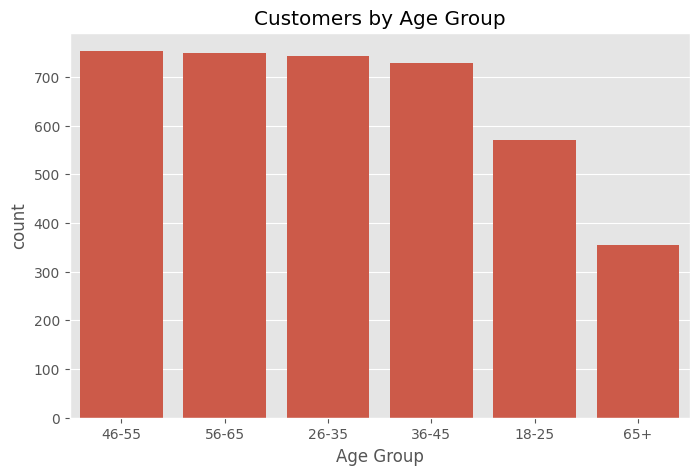

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Age Group",
    order=df["Age Group"].value_counts().index
)

plt.title("Customers by Age Group")
plt.show()

# 4. Purchase Analysis

# Chart 4: Purchase Amount Distribution

Are most purchases small or expensive

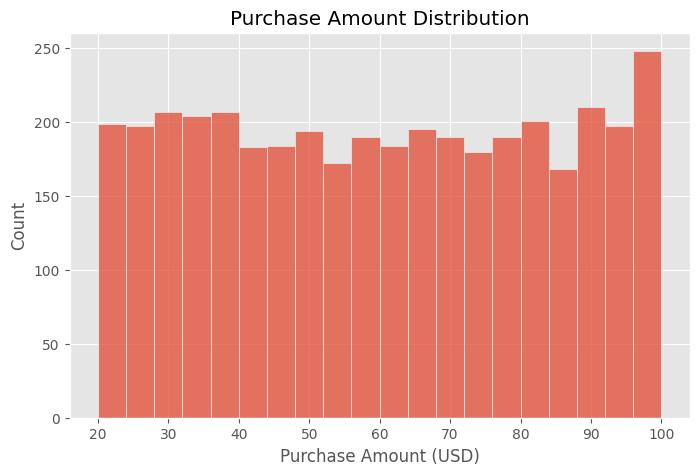

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Purchase Amount (USD)"],
    bins=20
)

plt.title("Purchase Amount Distribution")
plt.show()

# Chart 5: Average Purcases by Gender

Which gender spends more on average?

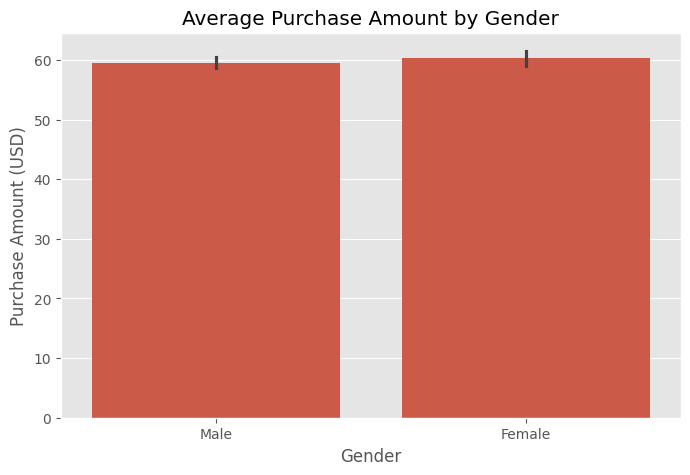

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="Gender",
    y="Purchase Amount (USD)"
)

plt.title("Average Purchase Amount by Gender")
plt.show()

# Chart 6: Purchase by Age group

Which age group has the highest average spending?

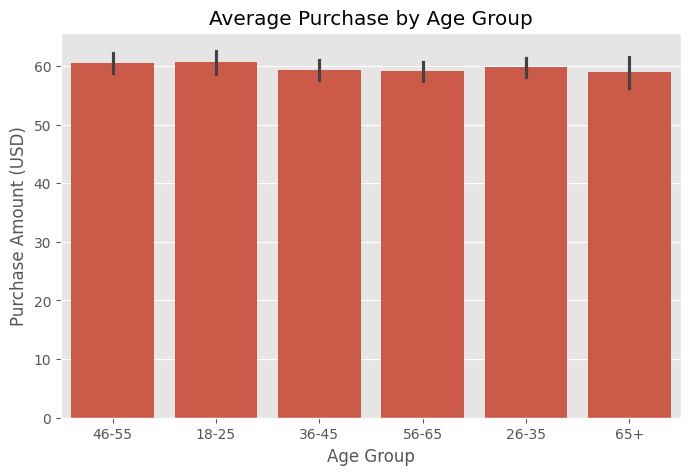

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="Age Group",
    y="Purchase Amount (USD)"
)

plt.title("Average Purchase by Age Group")
plt.show()

# 5. Product Analysis

# Chart 7:

Which product category is purchased most frequently?

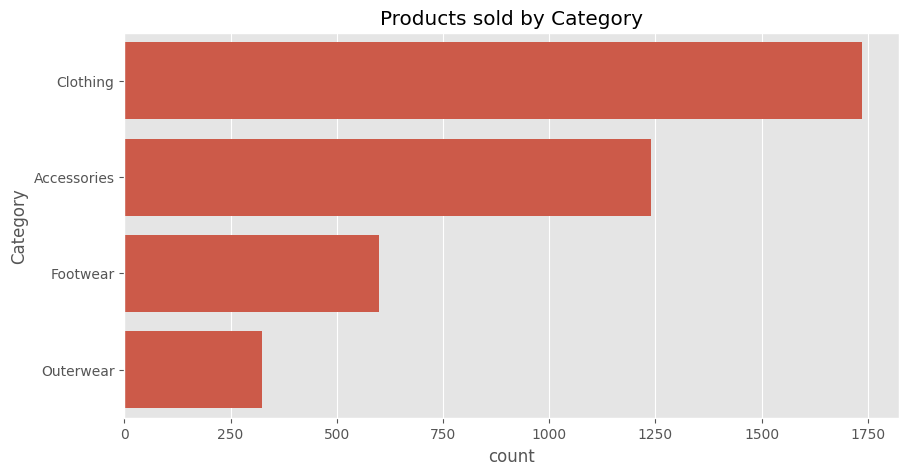

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="Category",
    order=df["Category"].value_counts().index
)

plt.title("Products sold by Category")
plt.show()

# Chart 8: Revenue by Category

Which category generates the highest revenue?

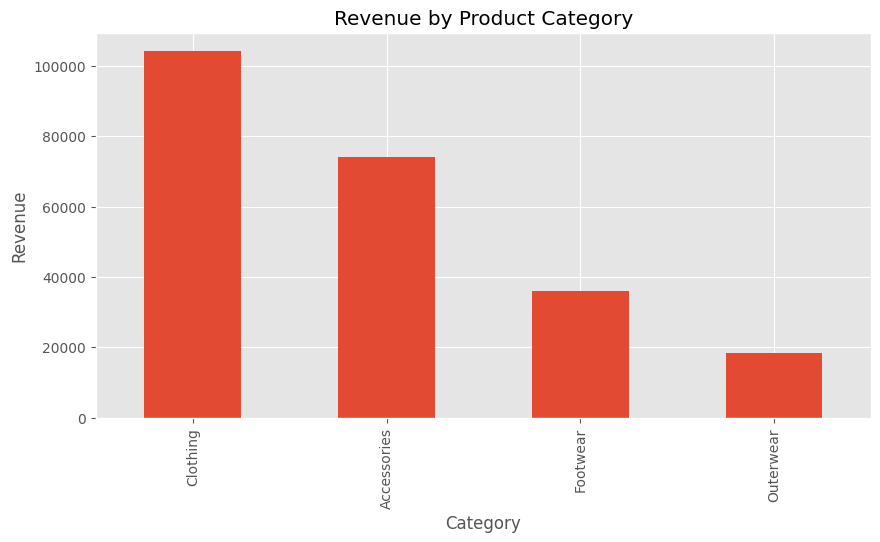

In [ ]:
category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

# Chart 9: Top 10 Purchased Items

Which products are most popular?

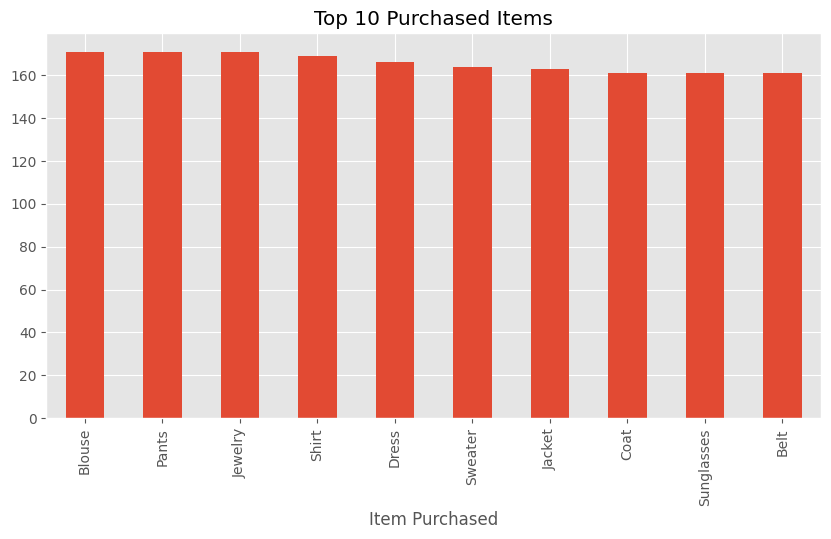

In [11]:
top_items = df["Item Purchased"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_items.plot(kind="bar")

plt.title("Top 10 Purchased Items")
plt.show()

# 6. Location Analysis

# Chart 10: Top 10 States by Customers

Which locations contribute the most customers?

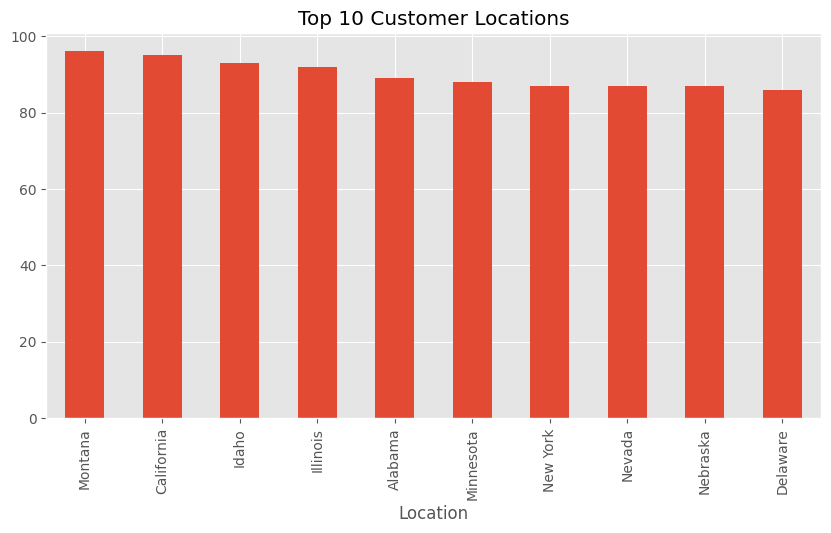

In [12]:
top_states = df["Location"].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_states.plot(kind="bar")

plt.title("Top 10 Customer Locations")
plt.show()

# 7. Payment Analysis

# Chart 11: Payment Methods

Which payment method is most preferred?

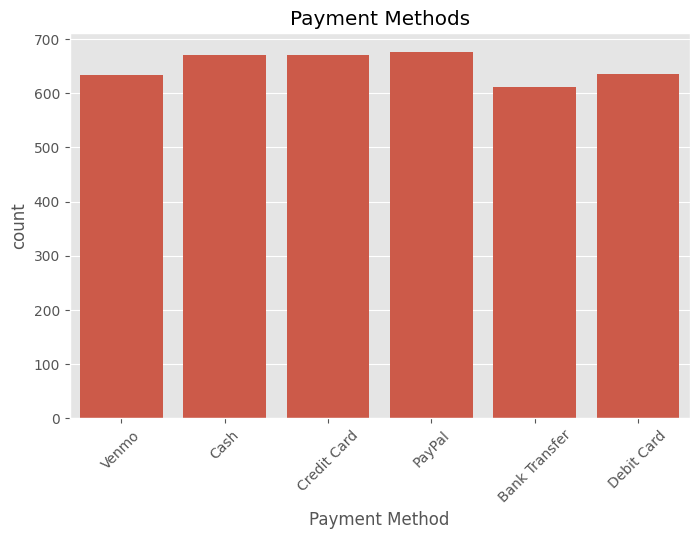

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Payment Method"
)
plt.xticks(rotation=45)

plt.title("Payment Methods")
plt.show()

# 8. Subscription Analysis

# Chart 12: Subscription Stats

What proportion of customers are subscribers?

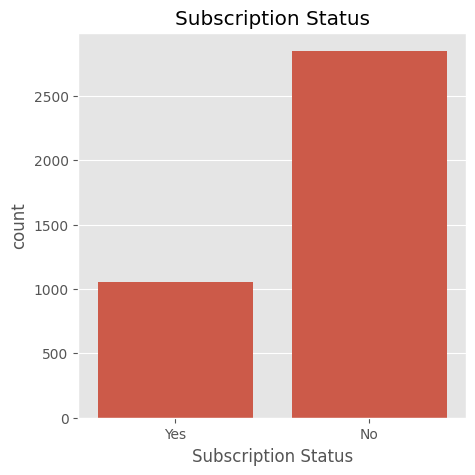

In [14]:
plt.figure(figsize=(5,5))
sns.countplot(
    data=df,
    x="Subscription Status"
)

plt.title("Subscription Status")
plt.show()

# Chart 13: Subscription vs Purchase Amount

Do subscribers spend more?

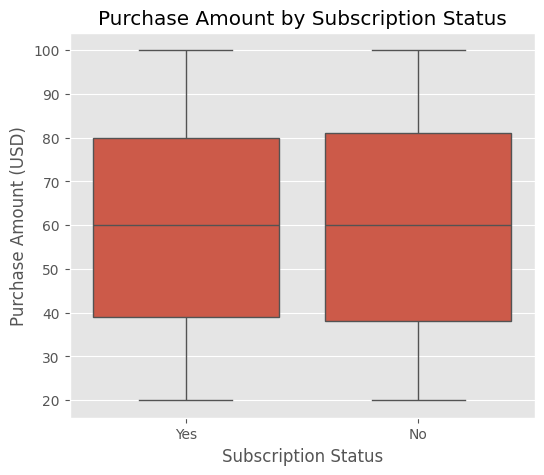

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="Subscription Status",
    y="Purchase Amount (USD)"
)

plt.title("Purchase Amount by Subscription Status")
plt.show()

# 9. Discount Analysis

# Chart 14: Discount Applied

How many purchases use discounts?

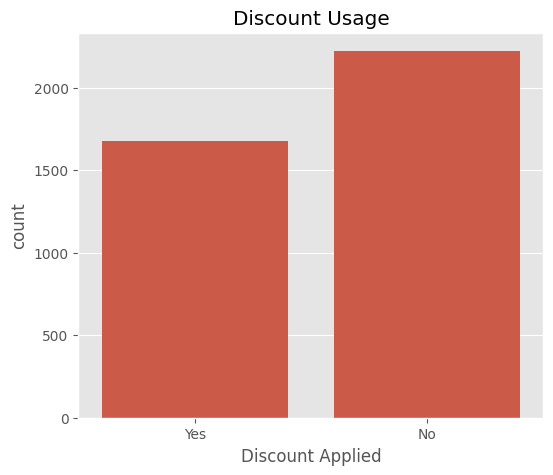

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x="Discount Applied"
)

plt.title("Discount Usage")
plt.show()

# 10. Customer Satisfaction

# Chart 15: Review Ratings

Are customers generally satisfied with their purchases?

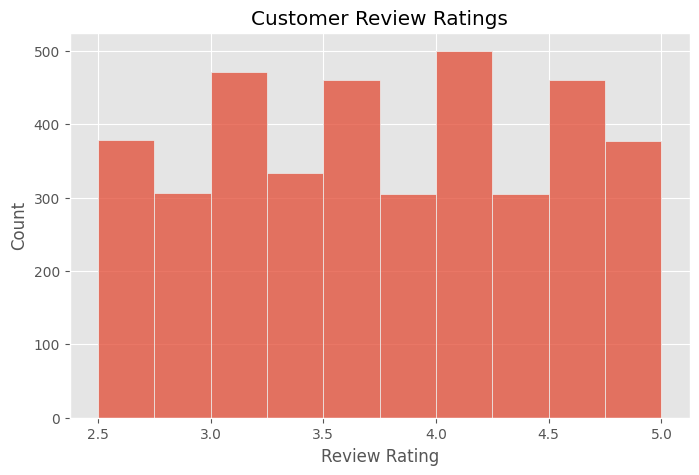

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Review Rating"],
    bins=10
)

plt.title("Customer Review Ratings")
plt.show()

# 11. Correction Analysis

Which numerical variables are strongly related?
Are there any surprising correlations?

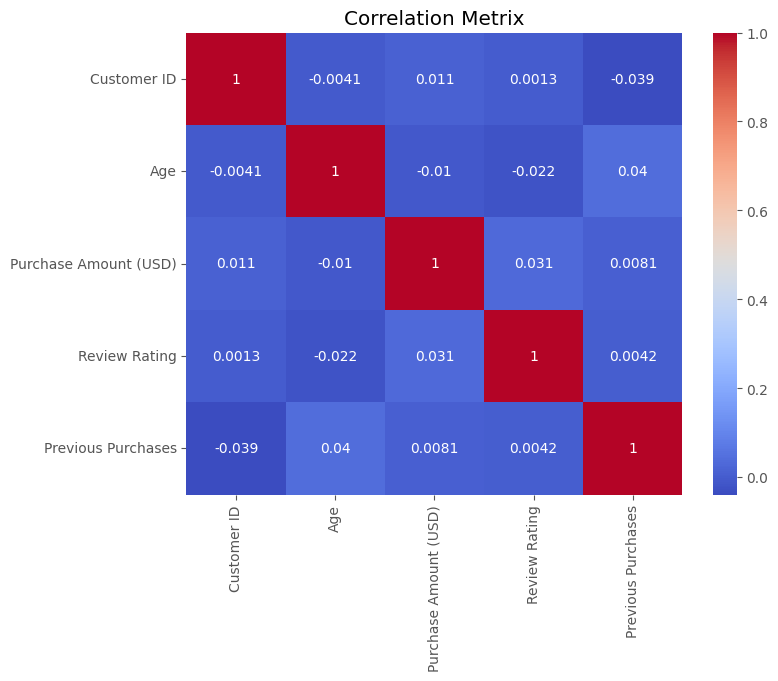

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Metrix")
plt.show()

# Customer Segmentation

# Part 1: Customer Spending Analysis

1. Top 10 Highest Spending Customers

This identify the most valuable customers. Businesses can target them with loyalty rewards or exclusive offers.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [17]:
df = pd.read_csv("cleaned_customer_data.csv")

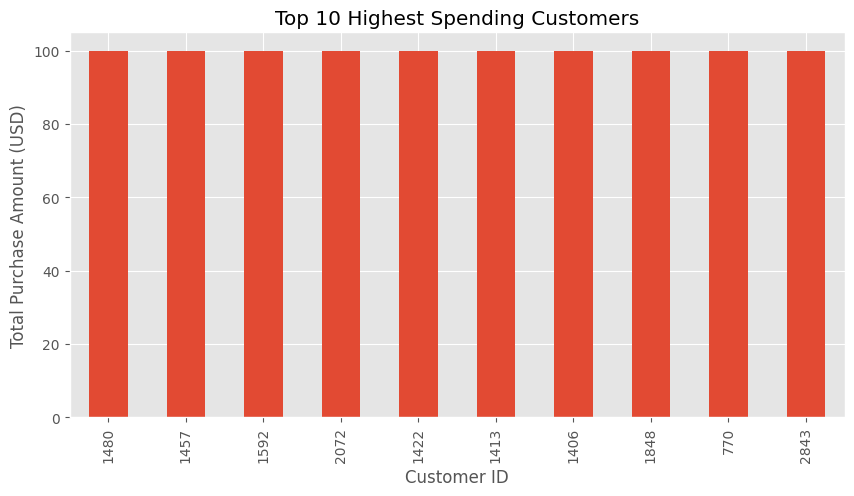

In [18]:
top_customers = (
    df.groupby("Customer ID")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")

plt.title("Top 10 Highest Spending Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Purchase Amount (USD)")
plt.show()

2. Average Spending by Customer

(We already did visualization for this)

In [ ]:
gender_spending = (
    df.groupby("Gender")["Purchase Amount (USD)"]
      .mean()
)

print(gender_spending)

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


3. Spending by Age Group

Which age group is the most influential?

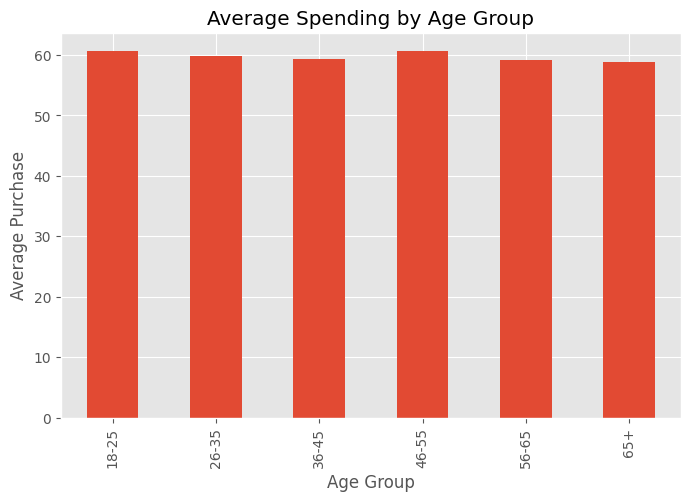

In [19]:
age_spending = (
    df.groupby("Age Group")["Purchase Amount (USD)"]
    .mean()
)

plt.figure(figsize=(8,5))
age_spending.plot(kind="bar")

plt.title("Average Spending by Age Group")
plt.ylabel("Average Purchase")
plt.show()

# Part 2: Product Performance

4. Revenue by Product Category

In [20]:
category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


5. Average Purchase by Category

some categories may have fewer sales but much higher average purchase values.

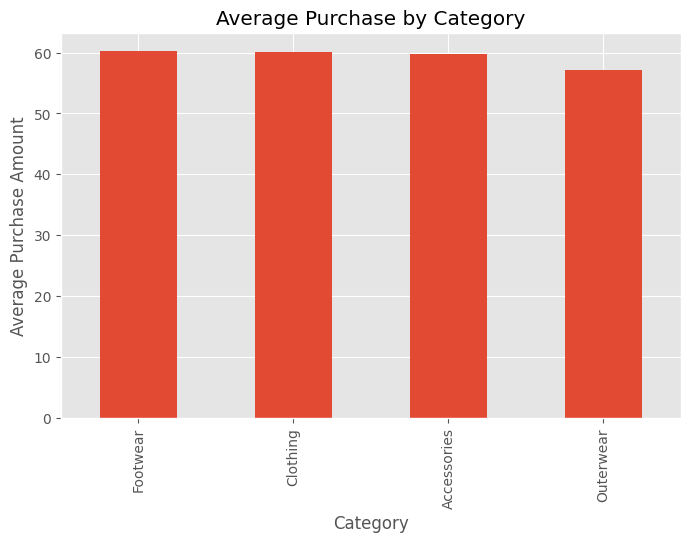

In [ ]:
avg_category = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
avg_category.plot(kind="bar")

plt.title("Average Purchase by Category")
plt.ylabel("Average Purchase Amount")
plt.show()

6. Most Popular Products

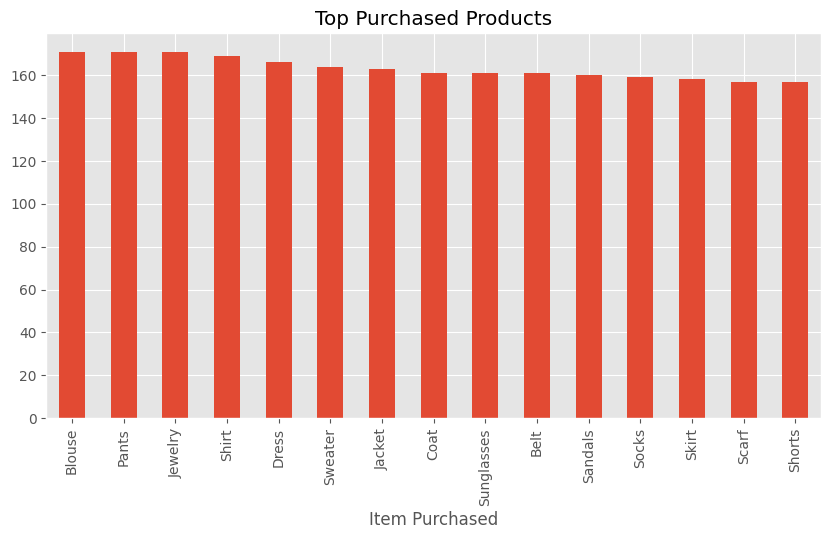

In [21]:
top_products = (
    df["Item Purchased"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title("Top Purchased Products")
plt.show()

# Part 3: Customer Preferences

7. Favourite Payment Method

In [ ]:
payment = (
    df["Payment Method"]
    .value_counts()
)

print(payment)

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


8. Favourite Shipping Type

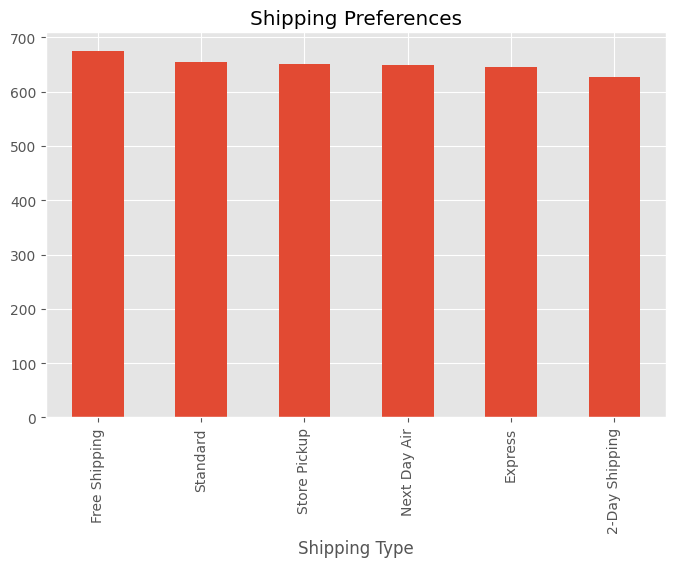

In [22]:
shipping = (
    df["Shipping Type"]
    .value_counts()
)

plt.figure(figsize = (8,5))
shipping.plot(kind="bar")

plt.title("Shipping Preferences")
plt.show()

9. Preferred Size

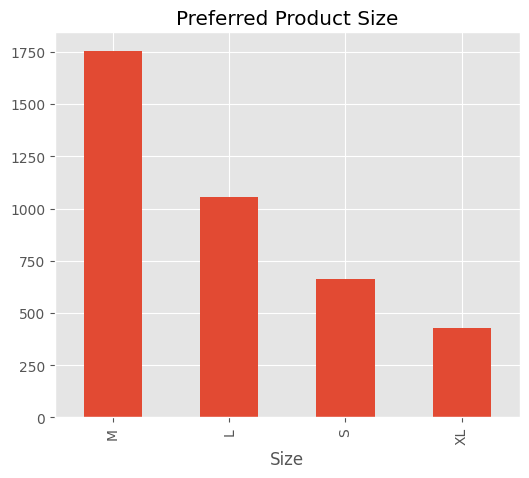

In [ ]:
size = (
    df["Size"]
    .value_counts()
)

plt.figure(figsize=(6,5))
size.plot(kind="bar")

plt.title("Preferred Product Size")
plt.show()

9. Favourite Color

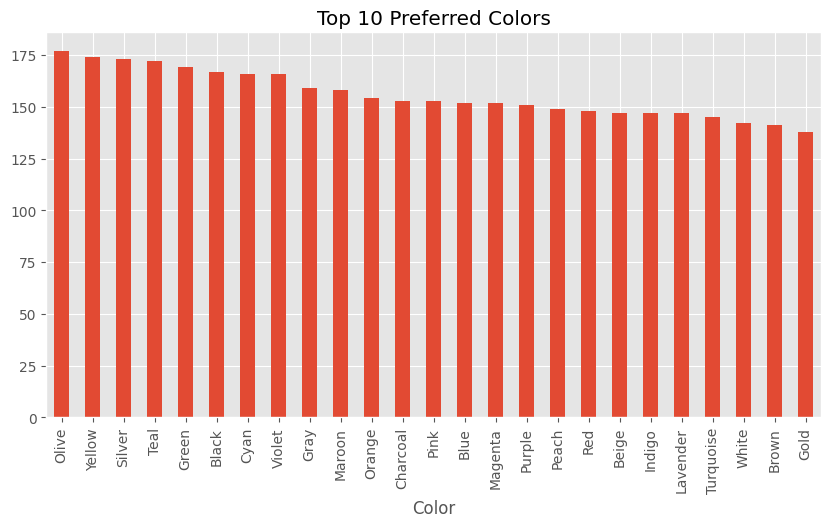

In [ ]:
color = (
    df["Color"]
    .value_counts()
)

plt.figure(figsize=(10,5))
color.plot(kind = "bar")

plt.title("Top 10 Preferred Colors")
plt.show()

# Part 4: Discounts and Promotions

11. Do Discounts Increase Spending?

Do customers spend more when discounts are available?

In [ ]:
discount = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
    .mean()
)

print(discount)

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64


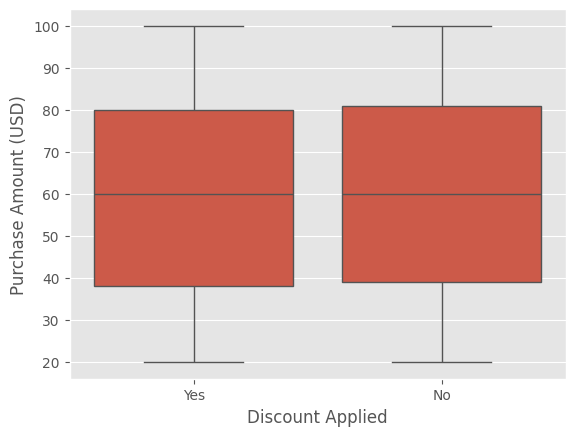

In [ ]:
sns.boxplot(
    data=df,
    x="Discount Applied",
    y="Purchase Amount (USD)"
)

plt.show()

12. Promo Code Usage

In [ ]:
promo = (
    df.groupby("Promo Code Used")["Purchase Amount (USD)"]
    .mean()
)

print(promo)

Promo Code Used
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64


# Part 5: Customer Loyalty

13. Subscription Status

Are subscribers more valuable than non-subscribers?

In [ ]:
subscription = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
)

print(subscription)

                     count       mean     sum
Subscription Status                          
No                    2847  59.865121  170436
Yes                   1053  59.491928   62645


14. Previous Purchases vs Purchase Amount

Do loyal customers spend more?

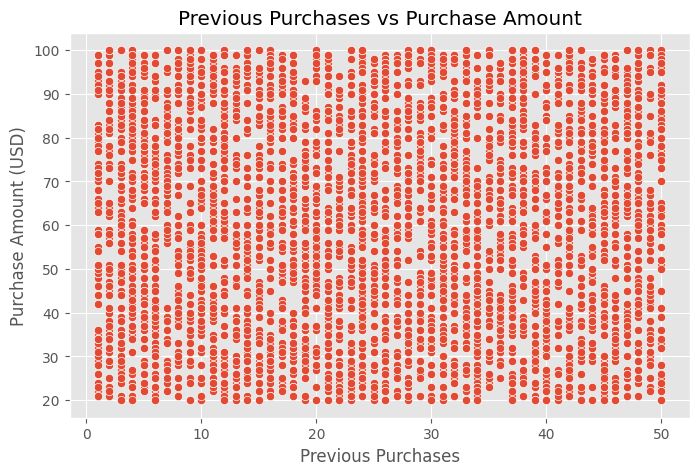

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Previous Purchases",
    y="Purchase Amount (USD)"
)

plt.title("Previous Purchases vs Purchase Amount")
plt.show()

# Part 6: Review Rarings

15. Rating vs Puchase Amount

Do expensive purchases receive better ratings?

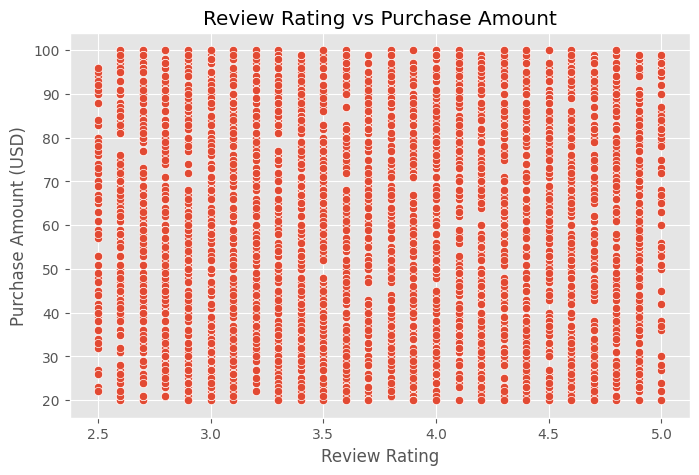

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Review Rating",
    y="Purchase Amount (USD)"
)

plt.title("Review Rating vs Purchase Amount")
plt.show()

# Part 7: Cross Analysis

These analysis are especially useful in dashboards

Revenue by Gender and Category

In [25]:
pivot = pd.pivot_table(
    df,
    values= "Purchase Amount (USD)",
    index= "Category",
    columns="Gender",
    aggfunc="sum"
)

pivot

Gender,Female,Male
Category,,
Accessories,23819,50381
Clothing,33636,70628
Footwear,11835,24258
Outerwear,5901,12623


Visualize

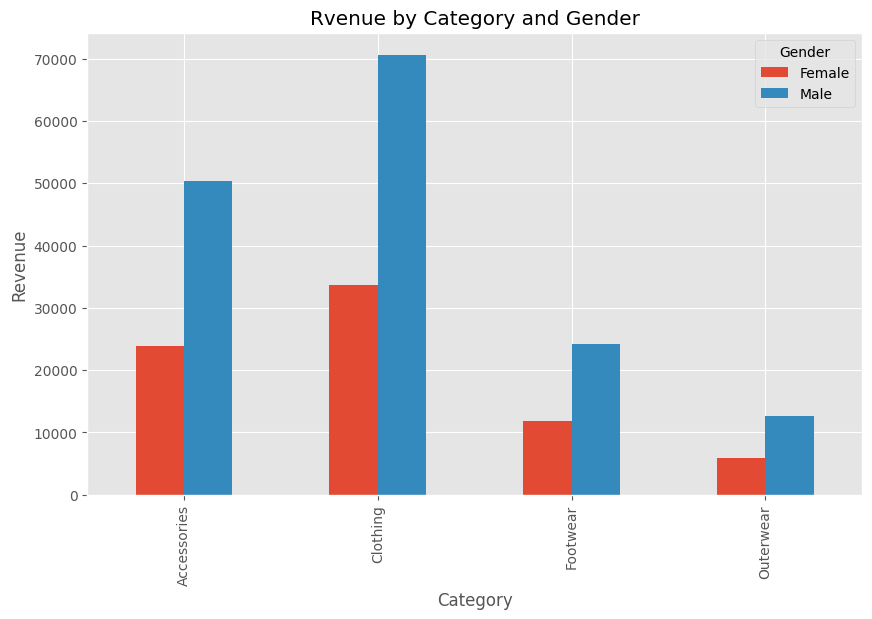

In [26]:
pivot.plot(kind="bar", figsize=(10,6))

plt.title("Rvenue by Category and Gender")
plt.ylabel("Revenue")
plt.show()

Revenue by Season

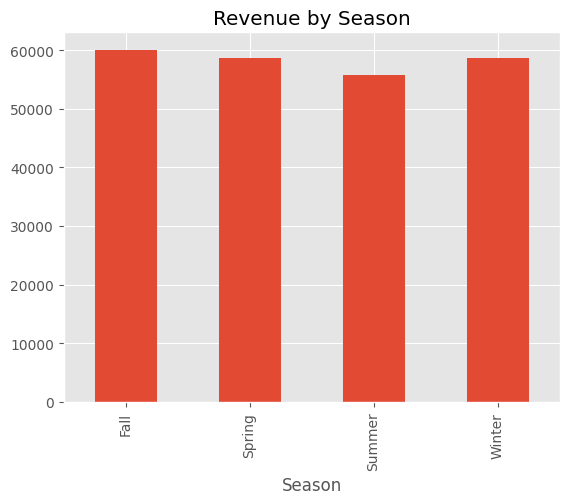

In [ ]:
season_sales = (
    df.groupby("Season")["Purchase Amount (USD)"]
    .sum()
)

season_sales.plot(kind="bar")

plt.title("Revenue by Season")
plt.show()

Payment Method by Gender

In [ ]:
payment_gender = pd.crosstab(
    df["Payment Method"],
    df["Gender"]
)

payment_gender

Gender,Female,Male
Payment Method,,
Bank Transfer,203,409
Cash,212,458
Credit Card,223,448
Debit Card,181,455
PayPal,221,456
Venmo,208,426


Visualize

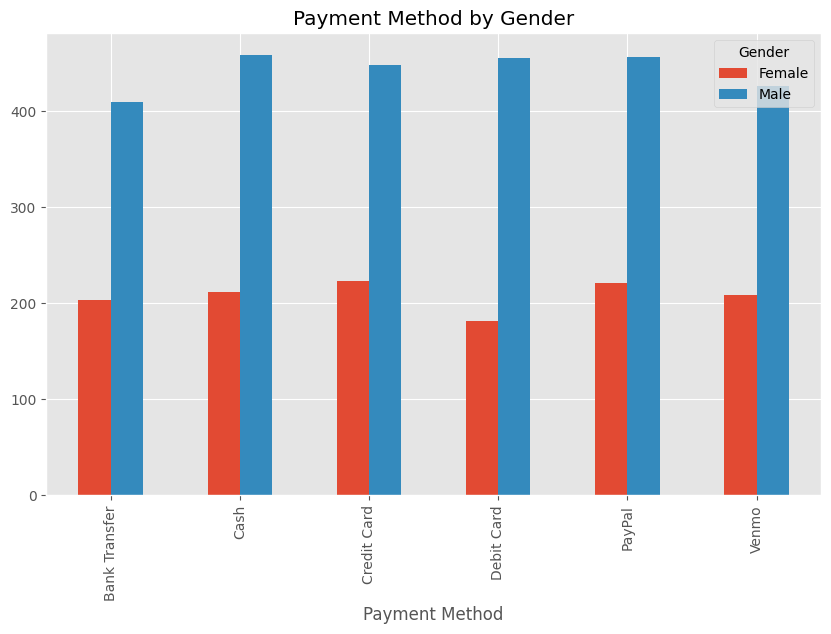

In [ ]:
payment_gender.plot(kind="bar", figsize=(10,6))

plt.title("Payment Method by Gender")
plt.show()

Results:

The top product category contributes the highest share of total revenue, making it a priority for inventory planning.
Customers in the highest-spending age group have the greatest average purchase amount and are strong candidates for premium marketing campaigns.
Subscribers generate higher average revenue than non-subsscribers, suggesting that subscription programs improve customer value.
Customers using certain payment methods may exhibit higher average purchase values than others.
Seasonal patterns indicate opportunities for targeted promotions during high-performing seasons.

# Machine Learning

# 1. Import Required Libraries

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [28]:
df = pd.read_csv("cleaned_customer_data.csv")

# 2. Select Features

We'll use only numerical features that describe customer behaviour.

In [29]:
features = df[
    [
        "Age",
        "Purchase Amount (USD)",
        "Previous Purchases",
        "Review Rating"
    ]
]

# 3. Scale the Data

K-Means performs better when features are on the same scale.

In [32]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# 4. Find the Optimal Number of Clusters (Elbow Method)

In [33]:
wcss = []

for i in range(1,11):
  model = KMeans(
      n_clusters = i,
      random_state=42,
      n_init=10
  )

  model.fit(scaled_features)
  wcss.append(model.inertia_)

Plot the Elbow Curve


Interpretation:

Look for the point where the curve starts flattening. Usually, it will be around 3-5 clusters. Let's assume 4 clusters.

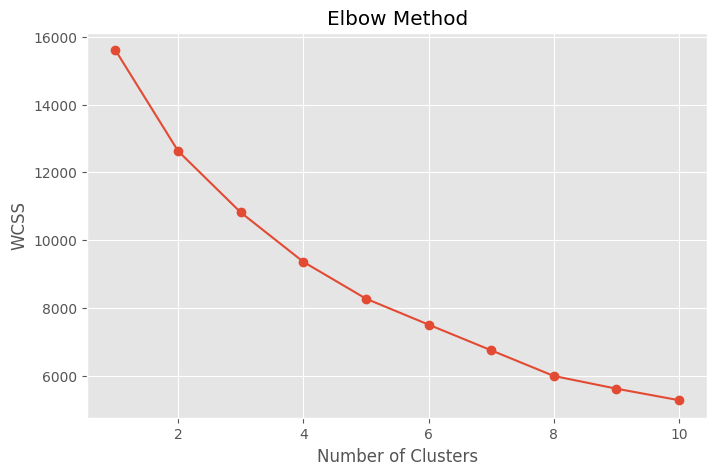

In [34]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show(

)

# 5. Train K-Means

In [37]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

# 6. Check Cluster Sizes

In [38]:
df["Cluster"].value_counts()

,count
Cluster,
2,986
3,979
1,969
0,966


# 7. Analyze the Clusters

This table helps you understand the characteristics of each cluster.

In [39]:
cluster_summary = (
    df.groupby("Cluster")[
        [
            "Age",
            "Purchase Amount (USD)",
            "Previous Purchases",
            "Review Rating"
        ]
    ]
    .mean()
)

print(cluster_summary)

               Age  Purchase Amount (USD)  Previous Purchases  Review Rating
Cluster                                                                     
0        56.218427              82.076605           26.759834       3.963768
1        31.328173              54.860681           24.984520       4.426316
2        32.585193              64.758621           22.440162       3.088540
3        56.255363              37.572012           27.257406       3.535649


# 8. Visualize the Clusters

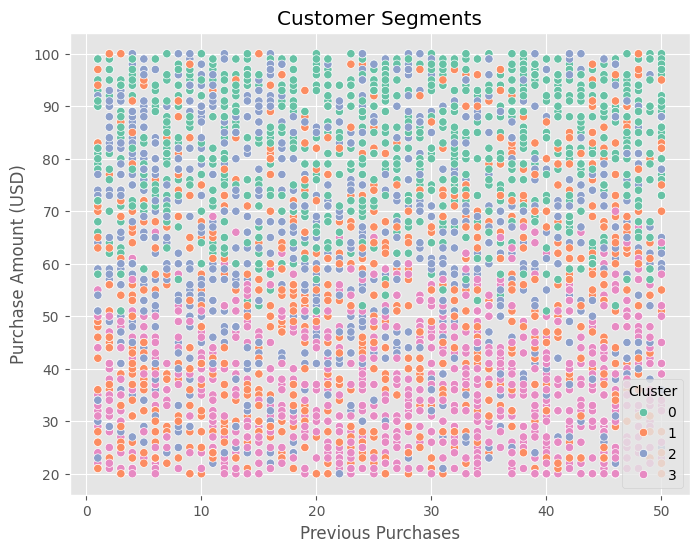

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Previous Purchases",
    y="Purchase Amount (USD)",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")
plt.show()

# 9. Profile Each Cluster

Create a more detailed summary

In [41]:
cluster_profile = (
    df.groupby("Cluster")
    .agg({
        "Age":"mean",
        "Purchase Amount (USD)":"mean",
        "Previous Purchases":"mean",
        "Review Rating":"mean",
        "Customer ID":"count"
    })
    .rename(columns={"Customer ID":"Customers"})
)

print(cluster_profile)

               Age  Purchase Amount (USD)  Previous Purchases  Review Rating  \
Cluster                                                                        
0        56.218427              82.076605           26.759834       3.963768   
1        31.328173              54.860681           24.984520       4.426316   
2        32.585193              64.758621           22.440162       3.088540   
3        56.255363              37.572012           27.257406       3.535649   

         Customers  
Cluster             
0              966  
1              969  
2              986  
3              979  


In [42]:
cluster_summary.style.background_gradient(cmap="Blues")

,Age,Purchase Amount (USD),Previous Purchases,Review Rating
Cluster,,,,
0,56.218427,82.076605,26.759834,3.963768
1,31.328173,54.860681,24.984520,4.426316
2,32.585193,64.758621,22.440162,3.088540
3,56.255363,37.572012,27.257406,3.535649


In [43]:
cluster_profile

,Age,Purchase Amount (USD),Previous Purchases,Review Rating,Customers
Cluster,,,,,
0,56.218427,82.076605,26.759834,3.963768,966
1,31.328173,54.860681,24.984520,4.426316,969
2,32.585193,64.758621,22.440162,3.088540,986
3,56.255363,37.572012,27.257406,3.535649,979


In [44]:
df.to_csv("customer_segmented.csv", index = False)